# 15 — Multi-session brain-model alignment with RSA, CKA, and encoding

This notebook aligns neural latent manifolds with analytic visual features and optional DNN/ViT features when available.

## Setup and asset index

In [1]:

from pathlib import Path
import os
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Edit this path only if your project has moved.
PROJECT_ROOT = Path(
    os.environ.get(
        "LATENT_MANIFOLD_PROJECT_ROOT",
        r"C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies",
    )
).resolve()

SRC_DIR = PROJECT_ROOT / "src"
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT does not exist: {PROJECT_ROOT}")
if not SRC_DIR.exists():
    raise FileNotFoundError(f"src directory does not exist: {SRC_DIR}")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
os.chdir(PROJECT_ROOT)

cfg_path = PROJECT_ROOT / "configs" / "publication_upgrade.yaml"
if not cfg_path.exists():
    raise FileNotFoundError(f"Could not find publication config: {cfg_path}")
with cfg_path.open("r", encoding="utf-8") as f:
    pub_cfg = yaml.safe_load(f)
cfg = pub_cfg

# Versioned namespace. This prevents accidental overwriting of older publication outputs.
PUBLICATION_RUN_LABEL = os.environ.get("PUBLICATION_RUN_LABEL", "publication_upgrade_v3_multisession")
ALLOW_CANONICAL_PUBLICATION_WRITE = os.environ.get("ALLOW_CANONICAL_PUBLICATION_WRITE", "0") == "1"
if PUBLICATION_RUN_LABEL == "publication_upgrade" and not ALLOW_CANONICAL_PUBLICATION_WRITE:
    raise RuntimeError(
        "Refusing to write into the canonical publication_upgrade namespace. "
        "Use a versioned PUBLICATION_RUN_LABEL or set ALLOW_CANONICAL_PUBLICATION_WRITE=1 intentionally."
    )

class ProjectPaths:
    def __init__(self, root: Path, run_label: str):
        self.root = root
        self.configs_dir = root / "configs"
        self.data_dir = root / "data"
        self.external_dir = root / "data" / "external"
        self.raw_dir = root / "data" / "raw"
        self.interim_dir = root / "data" / "interim"
        self.processed_dir = root / "data" / "processed"
        self.versioned_processed_dir = self.processed_dir / run_label
        self.reports_dir = root / "reports"
        self.tables_dir = root / "reports" / "tables"
        self.figures_dir = root / "reports" / "figures"
        self.html_dir = root / "reports" / "html"
        self.publication_tables_dir = root / "reports" / "tables" / run_label
        self.publication_figures_dir = root / "reports" / "figures" / run_label
        self.manuscript_dir = root / "manuscript" / "top_journal_scaffold"
        for d in [
            self.versioned_processed_dir,
            self.publication_tables_dir,
            self.publication_figures_dir,
            self.manuscript_dir,
        ]:
            d.mkdir(parents=True, exist_ok=True)

paths = ProjectPaths(PROJECT_ROOT, PUBLICATION_RUN_LABEL)

def save_table(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path

def save_figure(fig, path, dpi=300):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# Upgrade helper functions shipped with this patch.
from v1_manifold_publication.multisession_core import (
    build_multisession_asset_index,
    candidate_feature_files,
    choose_best_feature_table,
    ready_sessions,
    movie_feature_targets,
    empirical_null_summary,
    safe_read_csv,
    safe_table_index,
    claim_gate_from_assets,
    ensure_table,
)

metadata_path = paths.external_dir / "allen_v1_natural_movie_experiments.csv"
asset_index = build_multisession_asset_index(paths, metadata_path=metadata_path)
save_table(asset_index, paths.publication_tables_dir / "00_multisession_asset_index.csv")

print("Using PROJECT_ROOT:", PROJECT_ROOT)
print("Publication run label:", PUBLICATION_RUN_LABEL)
print("Publication tables:", paths.publication_tables_dir)
print("Publication figures:", paths.publication_figures_dir)
print("Versioned processed dir:", paths.versioned_processed_dir)
display(asset_index)


Using PROJECT_ROOT: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies
Publication run label: publication_upgrade_v3_multisession
Publication tables: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v3_multisession
Publication figures: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\figures\publication_upgrade_v3_multisession
Versioned processed dir: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\publication_upgrade_v3_multisession


,session_id,feature_file,feature_shape,tensor_file,embedding_file,embedding_names,embedding_shapes,has_features,has_tensor,has_embeddings,ready_for_latent_decoding,ready_for_population_encoding,ready_for_full_neural_analysis
0,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap,cebra","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True
1,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True
2,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True


## Analytic/Gabor-like visual-feature alignment

In [2]:
# ---------------------------------------------------------------------
# Notebook 15: analytic visual-feature alignment across sessions
# ---------------------------------------------------------------------
# Tests whether neural embeddings align with analytic low-level visual
# feature representations derived from the movie frames.
# ---------------------------------------------------------------------

from v1_manifold_publication.brain_model_alignment import (
    compare_representations,
    analytic_gabor_like_features,
)

common_embeddings = ["pca", "pca_full", "umap", "isomap"]

all_rows = []
status_rows = []

ready = (
    asset_index
    .loc[asset_index["ready_for_latent_decoding"], "session_id"]
    .astype(str)
    .tolist()
)

print("Sessions ready for analytic alignment:", ready)
print("Common embeddings:", common_embeddings)

for session_id in ready:
    emb_path = Path(
        asset_index.loc[
            asset_index["session_id"].astype(str) == str(session_id),
            "embedding_file",
        ].iloc[0]
    )

    feature_path = choose_best_feature_table(
        candidate_feature_files(paths, session_id)
    )

    if feature_path is None:
        status_rows.append({
            "session_id": session_id,
            "stage": "analytic_alignment",
            "status": "skipped",
            "reason": "No feature table found.",
        })
        continue

    try:
        features = pd.read_csv(feature_path)

        model_features = analytic_gabor_like_features(features)

        if model_features.ndim != 2 or model_features.shape[0] != len(features):
            raise ValueError(
                f"Invalid analytic feature shape: {model_features.shape}; "
                f"expected first dimension {len(features)}."
            )

        model_reps = {
            "analytic_gabor_like_features": model_features
        }

        with np.load(emb_path, allow_pickle=False) as emb:
            neural_reps = {}

            for name in common_embeddings:
                if name not in emb.files:
                    status_rows.append({
                        "session_id": session_id,
                        "embedding": name,
                        "stage": "analytic_alignment",
                        "status": "skipped",
                        "reason": "Embedding not found.",
                    })
                    continue

                Z = emb[name]

                if Z.ndim != 2 or Z.shape[0] != len(features):
                    status_rows.append({
                        "session_id": session_id,
                        "embedding": name,
                        "stage": "analytic_alignment",
                        "status": "skipped",
                        "reason": f"Invalid embedding shape: {Z.shape}",
                    })
                    continue

                neural_reps[name] = Z

        print("\n" + "=" * 90)
        print("Session:", session_id)
        print("Embedding file:", emb_path)
        print("Feature file:", feature_path)
        print("Analytic feature shape:", model_features.shape)
        print("Neural reps:", {k: v.shape for k, v in neural_reps.items()})

        if not neural_reps:
            status_rows.append({
                "session_id": session_id,
                "stage": "analytic_alignment",
                "status": "skipped",
                "reason": "No usable neural representations.",
            })
            continue

        comp = compare_representations(
            neural_reps,
            model_reps,
        )

        if comp is None or comp.empty:
            status_rows.append({
                "session_id": session_id,
                "stage": "analytic_alignment",
                "status": "empty_result",
            })
            continue

        comp = comp.copy()
        comp["session_id"] = session_id
        comp["feature_file"] = str(feature_path)
        comp["embedding_file"] = str(emb_path)
        comp["claim_scope"] = "analytic_visual_feature_alignment"

        all_rows.append(comp)

        status_rows.append({
            "session_id": session_id,
            "stage": "analytic_alignment",
            "status": "completed",
            "n_neural_representations": len(neural_reps),
            "n_rows": len(comp),
        })

    except Exception as exc:
        status_rows.append({
            "session_id": session_id,
            "stage": "analytic_alignment",
            "status": "failed",
            "reason": repr(exc),
        })

brain_model_alignment = (
    pd.concat(all_rows, ignore_index=True)
    if all_rows
    else pd.DataFrame()
)

alignment_status = pd.DataFrame(status_rows)

save_table(
    brain_model_alignment,
    paths.publication_tables_dir / "15_brain_model_alignment_analytic_features.csv",
)

save_table(
    alignment_status,
    paths.publication_tables_dir / "15_brain_model_alignment_analytic_features_status.csv",
)

if brain_model_alignment.empty:
    print("No analytic alignment rows were produced.")
    display(alignment_status)
else:
    display(
        brain_model_alignment
        .sort_values(["linear_cka"], ascending=False)
        .head(40)
    )

    display(alignment_status)

Sessions ready for analytic alignment: ['500855614', '500964514', '501271265']
Common embeddings: ['pca', 'pca_full', 'umap', 'isomap']

Session: 500855614
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_embeddings.npz
Feature file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_publication_enhanced_frame_features.csv
Analytic feature shape: (900, 12)
Neural reps: {'pca': (900, 3), 'pca_full': (900, 20), 'umap': (900, 3), 'isomap': (900, 3)}

Session: 500964514
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500964514_embeddings.npz
Feature file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500964514_publication_enhanced_frame_features.csv
Analytic feature shape: (900, 12)
Neural reps: {'pca': (900, 3), 'pca_full': (900, 20), 'uma

,neural_representation,model_representation,n_samples,rsa_spearman,rsa_p,linear_cka,session_id,feature_file,embedding_file,claim_scope
6,umap,analytic_gabor_like_features,900,0.331039,0.000000e+00,0.574551,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
3,isomap,analytic_gabor_like_features,900,0.441282,0.000000e+00,0.351596,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
2,umap,analytic_gabor_like_features,900,0.491736,0.000000e+00,0.254288,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
1,pca_full,analytic_gabor_like_features,900,0.200616,0.000000e+00,0.240286,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
10,umap,analytic_gabor_like_features,900,0.341950,0.000000e+00,0.230562,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
5,pca_full,analytic_gabor_like_features,900,0.238723,0.000000e+00,0.209337,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
0,pca,analytic_gabor_like_features,900,0.113966,0.000000e+00,0.193820,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
11,isomap,analytic_gabor_like_features,900,0.153058,0.000000e+00,0.186230,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
9,pca_full,analytic_gabor_like_features,900,0.213027,0.000000e+00,0.179441,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment
8,pca,analytic_gabor_like_features,900,0.102591,0.000000e+00,0.082255,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,analytic_visual_feature_alignment


,session_id,stage,status,n_neural_representations,n_rows
0,500855614,analytic_alignment,completed,4,4
1,500964514,analytic_alignment,completed,4,4
2,501271265,analytic_alignment,completed,4,4


## DNN feature extraction

In [4]:
# ---------------------------------------------------------------------
# Notebook 15: extract actual DNN features from natural-movie frames
# ---------------------------------------------------------------------
# This cell makes DNN feature files real.
#
# It extracts frame-wise activations from pretrained and untrained ResNet-18
# for each Allen natural-movie session and saves them as .npy files.
#
# Output shape per file:
#     [n_movie_frames, n_dnn_features]
#
# After this cell, the deep-alignment cell can produce non-empty results.
# ---------------------------------------------------------------------

import os
import sys

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

DNN_BATCH_SIZE = int(os.environ.get("DNN_BATCH_SIZE", 16))
DNN_IMAGE_SIZE = int(os.environ.get("DNN_IMAGE_SIZE", 224))
DNN_DEVICE = os.environ.get("DNN_DEVICE", "cuda")  # use "cpu" if no GPU
DNN_OVERWRITE = os.environ.get("DNN_OVERWRITE", "0") == "1"

# ResNet layers to extract.
# layer4 is the strongest default candidate for high-level visual features.
# layer2/layer3 are useful intermediate visual representations.
DNN_LAYER_SPECS = [
    {
        "model_name": "resnet18",
        "control_type": "pretrained",
        "layer_name": "layer2",
    },
    {
        "model_name": "resnet18",
        "control_type": "pretrained",
        "layer_name": "layer3",
    },
    {
        "model_name": "resnet18",
        "control_type": "pretrained",
        "layer_name": "layer4",
    },
    {
        "model_name": "resnet18",
        "control_type": "pretrained",
        "layer_name": "avgpool",
    },
    {
        "model_name": "resnet18",
        "control_type": "untrained",
        "layer_name": "layer2",
    },
    {
        "model_name": "resnet18",
        "control_type": "untrained",
        "layer_name": "layer3",
    },
    {
        "model_name": "resnet18",
        "control_type": "untrained",
        "layer_name": "layer4",
    },
    {
        "model_name": "resnet18",
        "control_type": "untrained",
        "layer_name": "avgpool",
    },
]

print("DNN batch size:", DNN_BATCH_SIZE)
print("DNN image size:", DNN_IMAGE_SIZE)
print("Requested device:", DNN_DEVICE)
print("Overwrite existing files:", DNN_OVERWRITE)

# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------

try:
    import torch
    import torch.nn.functional as F
    import torchvision.models as tv_models
except Exception as exc:
    raise ImportError(
        "PyTorch/torchvision is required for DNN feature extraction. "
        "Install torch and torchvision in your environment first."
    ) from exc

if DNN_DEVICE == "cuda" and not torch.cuda.is_available():
    print("CUDA requested but not available. Falling back to CPU.")
    DNN_DEVICE = "cpu"

device = torch.device(DNN_DEVICE)
print("Using device:", device)

# ---------------------------------------------------------------------
# Load Allen natural-movie frames
# ---------------------------------------------------------------------

def load_natural_movie_template_for_session(session_id):
    """
    Load the natural movie template from the Allen Brain Observatory cache.

    Returns
    -------
    frames : np.ndarray
        Shape [n_frames, height, width] or [n_frames, height, width, channels].
    """
    from v1_manifold.data_access import (
        get_boc,
        get_experiment_data,
        get_stimulus_template,
    )
    from v1_manifold.config import load_config, get_paths

    base_cfg = load_config(paths.root / "configs" / "default.yaml")
    base_paths = get_paths(base_cfg)

    boc = get_boc(base_paths.allen_manifest)
    data_set = get_experiment_data(boc, int(session_id))

    stimulus_name = cfg.get(
        "cohort",
        {},
    ).get(
        "natural_movie_stimuli",
        ["natural_movie_one"],
    )[0]

    frames = get_stimulus_template(data_set, stimulus_name)

    if frames is None:
        raise RuntimeError(
            f"Allen stimulus template was not available for session {session_id}."
        )

    frames = np.asarray(frames)

    if frames.ndim not in [3, 4]:
        raise ValueError(f"Expected movie frames with 3 or 4 dimensions, got {frames.shape}")

    return frames


# ---------------------------------------------------------------------
# Frame preprocessing
# ---------------------------------------------------------------------

def frames_to_tensor_batch(frames_batch, image_size=224, device="cpu"):
    """
    Convert a batch of movie frames into ImageNet-normalized tensors.

    Input
    -----
    frames_batch : np.ndarray
        [B, H, W] grayscale or [B, H, W, C].

    Output
    ------
    x : torch.Tensor
        [B, 3, image_size, image_size]
    """
    arr = np.asarray(frames_batch)

    if arr.ndim == 3:
        # [B, H, W] -> [B, H, W, 1]
        arr = arr[..., None]

    if arr.ndim != 4:
        raise ValueError(f"Expected batch with 4 dimensions after expansion, got {arr.shape}")

    # Convert to float32
    arr = arr.astype(np.float32)

    # Normalize frame intensity to [0, 1]
    # Handles uint8-like and float-like Allen templates.
    finite = np.isfinite(arr)

    if not finite.any():
        raise ValueError("Frame batch contains no finite values.")

    arr_min = float(np.nanmin(arr))
    arr_max = float(np.nanmax(arr))

    if arr_max > 1.5:
        arr = arr / 255.0
    else:
        arr = arr - arr_min
        denom = arr_max - arr_min
        if denom > 1e-12:
            arr = arr / denom

    arr = np.clip(arr, 0.0, 1.0)

    # [B, H, W, C] -> [B, C, H, W]
    x = torch.from_numpy(arr).permute(0, 3, 1, 2).contiguous()

    # Convert grayscale or non-3-channel images to 3 channels
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    elif x.shape[1] > 3:
        x = x[:, :3, :, :]
    elif x.shape[1] == 2:
        x = torch.cat([x, x[:, :1, :, :]], dim=1)

    x = x.to(device=device, dtype=torch.float32)

    # Resize to model input size
    x = F.interpolate(
        x,
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False,
    )

    # ImageNet normalization
    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        device=device,
        dtype=torch.float32,
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        device=device,
        dtype=torch.float32,
    ).view(1, 3, 1, 1)

    x = (x - mean) / std

    return x


# ---------------------------------------------------------------------
# Model loading
# ---------------------------------------------------------------------

def load_resnet18(control_type):
    """
    Load pretrained or untrained ResNet-18.

    For pretrained weights, torchvision may need internet access unless
    the weights are already cached locally.
    """
    control_type = str(control_type).lower()

    if control_type == "pretrained":
        try:
            weights = tv_models.ResNet18_Weights.DEFAULT
            model = tv_models.resnet18(weights=weights)
        except Exception as exc:
            raise RuntimeError(
                "Could not load pretrained ResNet-18 weights. "
                "This usually means the weights are not cached and internet access is unavailable. "
                "Run once with internet access, or switch this layer spec to untrained."
            ) from exc

    elif control_type == "untrained":
        model = tv_models.resnet18(weights=None)

    else:
        raise ValueError(f"Unknown control_type: {control_type}")

    model.eval()
    return model


def get_module_by_name(model, layer_name):
    """
    Get a named module from the model.
    """
    modules = dict(model.named_modules())

    if layer_name not in modules:
        raise KeyError(
            f"Layer {layer_name!r} not found. Available examples: "
            f"{list(modules.keys())[:30]}"
        )

    return modules[layer_name]


# ---------------------------------------------------------------------
# Activation extraction
# ---------------------------------------------------------------------

@torch.no_grad()
def extract_layer_features(frames, model, layer_name, batch_size=16, image_size=224, device="cpu"):
    """
    Extract frame-wise activations from a given model layer.

    Spatial activations are average-pooled across height/width to keep
    representations compact and comparable across layers.
    """
    model = model.to(device)
    model.eval()

    target_module = get_module_by_name(model, layer_name)
    captured = {}

    def hook_fn(module, inputs, output):
        captured["activation"] = output.detach()

    handle = target_module.register_forward_hook(hook_fn)

    features = []

    try:
        n_frames = int(frames.shape[0])

        for start in range(0, n_frames, batch_size):
            stop = min(start + batch_size, n_frames)
            batch = frames[start:stop]

            x = frames_to_tensor_batch(
                batch,
                image_size=image_size,
                device=device,
            )

            captured.clear()
            _ = model(x)

            if "activation" not in captured:
                raise RuntimeError(f"No activation captured for layer {layer_name}")

            act = captured["activation"]

            # If convolutional feature map: [B, C, H, W] -> [B, C]
            if act.ndim == 4:
                act = act.mean(dim=(2, 3))

            # If avgpool: [B, C, 1, 1] -> [B, C]
            elif act.ndim > 2:
                act = act.reshape(act.shape[0], -1)

            # If already [B, features], keep it.
            elif act.ndim == 2:
                pass

            else:
                act = act.reshape(act.shape[0], -1)

            features.append(act.cpu().numpy().astype(np.float32))

    finally:
        handle.remove()

    return np.concatenate(features, axis=0)


# ---------------------------------------------------------------------
# Run extraction for all ready sessions
# ---------------------------------------------------------------------

ready = (
    asset_index
    .loc[asset_index["ready_for_latent_decoding"], "session_id"]
    .astype(str)
    .tolist()
)

print("Sessions for DNN feature extraction:", ready)

dnn_rows = []
status_rows = []

for session_id in ready:
    print("\n" + "=" * 90)
    print("Session:", session_id)

    try:
        frames = load_natural_movie_template_for_session(session_id)
        print("Loaded frames:", frames.shape)

    except Exception as exc:
        status_rows.append({
            "session_id": session_id,
            "stage": "load_movie_frames",
            "status": "failed",
            "reason": repr(exc),
        })
        print("Frame loading failed:", repr(exc))
        continue

    for spec in DNN_LAYER_SPECS:
        model_name = spec["model_name"]
        control_type = spec["control_type"]
        layer_name = spec["layer_name"]

        out_path = (
            paths.versioned_processed_dir
            / f"session_{session_id}_{model_name}_{control_type}_{layer_name}_features.npy"
        )

        if out_path.exists() and not DNN_OVERWRITE:
            arr = np.load(out_path)
            status_rows.append({
                "session_id": session_id,
                "model_name": model_name,
                "control_type": control_type,
                "layer_name": layer_name,
                "stage": "dnn_feature_extraction",
                "status": "exists",
                "output_file": str(out_path),
                "shape": str(arr.shape),
            })
            print("Already exists:", out_path.name, arr.shape)
            continue

        try:
            if model_name == "resnet18":
                model = load_resnet18(control_type)
            else:
                raise ValueError(f"Unsupported model_name in this cell: {model_name}")

            feats = extract_layer_features(
                frames,
                model=model,
                layer_name=layer_name,
                batch_size=DNN_BATCH_SIZE,
                image_size=DNN_IMAGE_SIZE,
                device=device,
            )

            if feats.shape[0] != frames.shape[0]:
                raise ValueError(
                    f"Feature/frame mismatch: features={feats.shape}, frames={frames.shape}"
                )

            out_path.parent.mkdir(parents=True, exist_ok=True)
            np.save(out_path, feats)

            dnn_rows.append({
                "session_id": session_id,
                "model_name": model_name,
                "control_type": control_type,
                "layer_name": layer_name,
                "output_file": str(out_path),
                "n_frames": int(feats.shape[0]),
                "n_features": int(feats.shape[1]),
            })

            status_rows.append({
                "session_id": session_id,
                "model_name": model_name,
                "control_type": control_type,
                "layer_name": layer_name,
                "stage": "dnn_feature_extraction",
                "status": "saved",
                "output_file": str(out_path),
                "shape": str(feats.shape),
            })

            print("Saved:", out_path.name, feats.shape)

            # Free memory
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as exc:
            status_rows.append({
                "session_id": session_id,
                "model_name": model_name,
                "control_type": control_type,
                "layer_name": layer_name,
                "stage": "dnn_feature_extraction",
                "status": "failed",
                "output_file": str(out_path),
                "reason": repr(exc),
            })

            print("Failed:", model_name, control_type, layer_name, repr(exc))

dnn_feature_table = pd.DataFrame(dnn_rows)
dnn_feature_status = pd.DataFrame(status_rows)

save_table(
    dnn_feature_table,
    paths.publication_tables_dir / "15_dnn_extracted_feature_files.csv",
)

save_table(
    dnn_feature_status,
    paths.publication_tables_dir / "15_dnn_feature_extraction_status.csv",
)

display(dnn_feature_table)
display(dnn_feature_status)

DNN batch size: 16
DNN image size: 224
Requested device: cuda
Overwrite existing files: False
CUDA requested but not available. Falling back to CPU.
Using device: cpu
Sessions for DNN feature extraction: ['500855614', '500964514', '501271265']

Session: 500855614


c:\Users\Peter\.neuro\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Loaded frames: (900, 304, 608)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Peter/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [02:00<00:00, 388kB/s] 


Saved: session_500855614_resnet18_pretrained_layer2_features.npy (900, 128)
Saved: session_500855614_resnet18_pretrained_layer3_features.npy (900, 256)
Saved: session_500855614_resnet18_pretrained_layer4_features.npy (900, 512)
Saved: session_500855614_resnet18_pretrained_avgpool_features.npy (900, 512)
Saved: session_500855614_resnet18_untrained_layer2_features.npy (900, 128)
Saved: session_500855614_resnet18_untrained_layer3_features.npy (900, 256)
Saved: session_500855614_resnet18_untrained_layer4_features.npy (900, 512)
Saved: session_500855614_resnet18_untrained_avgpool_features.npy (900, 512)

Session: 500964514
Loaded frames: (900, 304, 608)
Saved: session_500964514_resnet18_pretrained_layer2_features.npy (900, 128)
Saved: session_500964514_resnet18_pretrained_layer3_features.npy (900, 256)
Saved: session_500964514_resnet18_pretrained_layer4_features.npy (900, 512)
Saved: session_500964514_resnet18_pretrained_avgpool_features.npy (900, 512)
Saved: session_500964514_resnet18_untr

,session_id,model_name,control_type,layer_name,output_file,n_frames,n_features
0,500855614,resnet18,pretrained,layer2,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,128
1,500855614,resnet18,pretrained,layer3,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,256
2,500855614,resnet18,pretrained,layer4,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,512
3,500855614,resnet18,pretrained,avgpool,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,512
4,500855614,resnet18,untrained,layer2,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,128
5,500855614,resnet18,untrained,layer3,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,256
6,500855614,resnet18,untrained,layer4,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,512
7,500855614,resnet18,untrained,avgpool,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,512
8,500964514,resnet18,pretrained,layer2,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,128
9,500964514,resnet18,pretrained,layer3,C:\Users\Peter\Documents\projects\NeuroAI\late...,900,256


,session_id,model_name,control_type,layer_name,stage,status,output_file,shape
0,500855614,resnet18,pretrained,layer2,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 128)"
1,500855614,resnet18,pretrained,layer3,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 256)"
2,500855614,resnet18,pretrained,layer4,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 512)"
3,500855614,resnet18,pretrained,avgpool,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 512)"
4,500855614,resnet18,untrained,layer2,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 128)"
5,500855614,resnet18,untrained,layer3,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 256)"
6,500855614,resnet18,untrained,layer4,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 512)"
7,500855614,resnet18,untrained,avgpool,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 512)"
8,500964514,resnet18,pretrained,layer2,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 128)"
9,500964514,resnet18,pretrained,layer3,dnn_feature_extraction,saved,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 256)"


In [6]:
# ---------------------------------------------------------------------
# Notebook 15: deep-model alignment with extracted ResNet-18 features
# ---------------------------------------------------------------------
# Compares neural embeddings with pretrained and untrained ResNet-18
# feature representations extracted from the same natural-movie frames.
# ---------------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

from v1_manifold_publication.brain_model_alignment import compare_representations

common_embeddings = ["pca", "pca_full", "umap", "isomap"]

rows = []
status_rows = []

ready = (
    asset_index
    .loc[asset_index["ready_for_latent_decoding"], "session_id"]
    .astype(str)
    .tolist()
)

print("Sessions ready for deep-model alignment:", ready)
print("Common neural embeddings:", common_embeddings)

for session_id in ready:
    emb_path = Path(
        asset_index.loc[
            asset_index["session_id"].astype(str) == str(session_id),
            "embedding_file",
        ].iloc[0]
    )

    model_files = (
        sorted(paths.versioned_processed_dir.glob(f"session_{session_id}_resnet18_*_features.npy"))
        + sorted(paths.processed_dir.glob(f"session_{session_id}_resnet18_*_features.npy"))
    )

    model_files = [
        f for f in model_files
        if "embedding" not in f.name.lower()
        and "cebra" not in f.name.lower()
    ]

    print("\n" + "=" * 90)
    print("Session:", session_id)
    print("Embedding file:", emb_path)
    print("Number of DNN feature files:", len(model_files))

    if not model_files:
        status_rows.append({
            "session_id": session_id,
            "stage": "deep_model_alignment",
            "status": "skipped",
            "reason": "No ResNet-18 feature .npy files found.",
        })
        continue

    try:
        with np.load(emb_path, allow_pickle=False) as emb:
            neural_reps = {}

            for name in common_embeddings:
                if name not in emb.files:
                    status_rows.append({
                        "session_id": session_id,
                        "embedding": name,
                        "stage": "deep_model_alignment",
                        "status": "skipped",
                        "reason": "Embedding not found.",
                    })
                    continue

                Z = emb[name]

                if Z.ndim != 2:
                    status_rows.append({
                        "session_id": session_id,
                        "embedding": name,
                        "stage": "deep_model_alignment",
                        "status": "skipped",
                        "reason": f"Expected 2D embedding, got {Z.shape}.",
                    })
                    continue

                neural_reps[name] = Z

        model_reps = {}

        for model_file in model_files:
            try:
                arr = np.load(model_file)

                if arr.ndim != 2:
                    status_rows.append({
                        "session_id": session_id,
                        "model_file": str(model_file),
                        "stage": "deep_model_alignment",
                        "status": "skipped",
                        "reason": f"Expected 2D model feature array, got {arr.shape}.",
                    })
                    continue

                if arr.shape[0] != 900:
                    status_rows.append({
                        "session_id": session_id,
                        "model_file": str(model_file),
                        "stage": "deep_model_alignment",
                        "status": "warning",
                        "reason": f"Unexpected frame count: {arr.shape[0]}.",
                    })

                model_name = model_file.stem.replace(f"session_{session_id}_", "")
                model_reps[model_name] = arr

                status_rows.append({
                    "session_id": session_id,
                    "model_file": str(model_file),
                    "model_representation": model_name,
                    "stage": "deep_model_alignment",
                    "status": "loaded",
                    "shape": str(arr.shape),
                })

            except Exception as exc:
                status_rows.append({
                    "session_id": session_id,
                    "model_file": str(model_file),
                    "stage": "deep_model_alignment",
                    "status": "failed",
                    "reason": repr(exc),
                })

        print("Neural reps:", {k: v.shape for k, v in neural_reps.items()})
        print("Model reps:", {k: v.shape for k, v in model_reps.items()})

        if neural_reps and model_reps:
            comp = compare_representations(
                neural_reps,
                model_reps,
            )

            if comp is not None and not comp.empty:
                comp = comp.copy()
                comp["session_id"] = session_id
                comp["embedding_file"] = str(emb_path)
                comp["claim_scope"] = "deep_model_alignment_resnet18"
                rows.append(comp)

                status_rows.append({
                    "session_id": session_id,
                    "stage": "deep_model_alignment",
                    "status": "completed",
                    "n_neural_representations": len(neural_reps),
                    "n_model_representations": len(model_reps),
                    "n_rows": len(comp),
                })
            else:
                status_rows.append({
                    "session_id": session_id,
                    "stage": "deep_model_alignment",
                    "status": "empty_result",
                })

    except Exception as exc:
        status_rows.append({
            "session_id": session_id,
            "stage": "deep_model_alignment",
            "status": "failed",
            "reason": repr(exc),
        })

deep_alignment = (
    pd.concat(rows, ignore_index=True)
    if rows
    else pd.DataFrame()
)

deep_alignment_status = pd.DataFrame(status_rows)

save_table(
    deep_alignment,
    paths.publication_tables_dir / "15_brain_model_alignment_deep_features.csv",
)

save_table(
    deep_alignment_status,
    paths.publication_tables_dir / "15_brain_model_alignment_deep_features_status.csv",
)

if deep_alignment.empty:
    print("No deep-alignment rows were produced.")
    display(deep_alignment_status.head(50))
else:
    display(
        deep_alignment
        .sort_values("linear_cka", ascending=False)
        .head(50)
    )

    display(deep_alignment_status.head(80))

Sessions ready for deep-model alignment: ['500855614', '500964514', '501271265']
Common neural embeddings: ['pca', 'pca_full', 'umap', 'isomap']

Session: 500855614
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_embeddings.npz
Number of DNN feature files: 8
Neural reps: {'pca': (900, 3), 'pca_full': (900, 20), 'umap': (900, 3), 'isomap': (900, 3)}
Model reps: {'resnet18_pretrained_avgpool_features': (900, 512), 'resnet18_pretrained_layer2_features': (900, 128), 'resnet18_pretrained_layer3_features': (900, 256), 'resnet18_pretrained_layer4_features': (900, 512), 'resnet18_untrained_avgpool_features': (900, 512), 'resnet18_untrained_layer2_features': (900, 128), 'resnet18_untrained_layer3_features': (900, 256), 'resnet18_untrained_layer4_features': (900, 512)}

Session: 500964514
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500964514_embeddin

,neural_representation,model_representation,n_samples,rsa_spearman,rsa_p,linear_cka,session_id,embedding_file,claim_scope
50,umap,resnet18_pretrained_layer3_features,900,0.397557,0.0,0.685064,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
48,umap,resnet18_pretrained_avgpool_features,900,0.556677,0.0,0.667823,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
51,umap,resnet18_pretrained_layer4_features,900,0.556677,0.0,0.667823,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
49,umap,resnet18_pretrained_layer2_features,900,0.352699,0.0,0.634482,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
16,umap,resnet18_pretrained_avgpool_features,900,0.446274,0.0,0.558519,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
19,umap,resnet18_pretrained_layer4_features,900,0.446274,0.0,0.558519,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
17,umap,resnet18_pretrained_layer2_features,900,0.472869,0.0,0.530532,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
18,umap,resnet18_pretrained_layer3_features,900,0.451316,0.0,0.512989,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
80,umap,resnet18_pretrained_avgpool_features,900,0.185712,0.0,0.436314,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18
83,umap,resnet18_pretrained_layer4_features,900,0.185712,0.0,0.436314,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,deep_model_alignment_resnet18


,session_id,model_file,model_representation,stage,status,shape,n_neural_representations,n_model_representations,n_rows
0,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_avgpool_features,deep_model_alignment,loaded,"(900, 512)",NaN,NaN,NaN
1,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer2_features,deep_model_alignment,loaded,"(900, 128)",NaN,NaN,NaN
2,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer3_features,deep_model_alignment,loaded,"(900, 256)",NaN,NaN,NaN
3,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer4_features,deep_model_alignment,loaded,"(900, 512)",NaN,NaN,NaN
4,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_avgpool_features,deep_model_alignment,loaded,"(900, 512)",NaN,NaN,NaN
5,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_layer2_features,deep_model_alignment,loaded,"(900, 128)",NaN,NaN,NaN
6,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_layer3_features,deep_model_alignment,loaded,"(900, 256)",NaN,NaN,NaN
7,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_layer4_features,deep_model_alignment,loaded,"(900, 512)",NaN,NaN,NaN
8,500855614,NaN,NaN,deep_model_alignment,completed,NaN,4.0,8.0,32.0
9,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_avgpool_features,deep_model_alignment,loaded,"(900, 512)",NaN,NaN,NaN


In [7]:
# ---------------------------------------------------------------------
# Notebook 15: summarize deep-model alignment across sessions
# ---------------------------------------------------------------------

deep_path = paths.publication_tables_dir / "15_brain_model_alignment_deep_features.csv"

if not deep_path.exists():
    raise FileNotFoundError(f"Missing deep alignment table: {deep_path}")

deep_alignment = pd.read_csv(deep_path)

if deep_alignment.empty:
    raise RuntimeError("Deep alignment table is empty. Run the deep-alignment cell first.")

required_cols = [
    "session_id",
    "neural_representation",
    "model_representation",
    "linear_cka",
    "rsa_spearman",
]

missing = [c for c in required_cols if c not in deep_alignment.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

def parse_resnet18_representation(name):
    """
    Expected examples:
        resnet18_pretrained_layer2_features
        resnet18_untrained_avgpool_features
    """
    name = str(name)

    parts = name.replace("_features", "").split("_")

    out = {
        "model_family": parts[0] if len(parts) > 0 else "unknown",
        "control_type": "unknown",
        "layer_name": "unknown",
    }

    if "pretrained" in parts:
        out["control_type"] = "pretrained"
    elif "untrained" in parts:
        out["control_type"] = "untrained"

    for layer in ["layer2", "layer3", "layer4", "avgpool"]:
        if layer in parts:
            out["layer_name"] = layer
            break

    return pd.Series(out)

parsed = deep_alignment["model_representation"].apply(parse_resnet18_representation)

deep_alignment_parsed = pd.concat(
    [deep_alignment.copy(), parsed],
    axis=1,
)

save_table(
    deep_alignment_parsed,
    paths.publication_tables_dir / "15_brain_model_alignment_deep_features_parsed.csv",
)

# Multi-session summary
deep_summary = (
    deep_alignment_parsed
    .groupby(
        ["neural_representation", "model_family", "control_type", "layer_name"],
        as_index=False,
    )
    .agg(
        n_sessions=("session_id", "nunique"),
        mean_linear_cka=("linear_cka", "mean"),
        median_linear_cka=("linear_cka", "median"),
        std_linear_cka=("linear_cka", "std"),
        mean_rsa_spearman=("rsa_spearman", "mean"),
        median_rsa_spearman=("rsa_spearman", "median"),
        std_rsa_spearman=("rsa_spearman", "std"),
    )
    .sort_values(
        ["mean_linear_cka", "mean_rsa_spearman"],
        ascending=False,
    )
)

save_table(
    deep_summary,
    paths.publication_tables_dir / "15_brain_model_alignment_deep_multisession_summary.csv",
)

display(deep_summary.head(40))

,neural_representation,model_family,control_type,layer_name,n_sessions,mean_linear_cka,median_linear_cka,std_linear_cka,mean_rsa_spearman,median_rsa_spearman,std_rsa_spearman
24,umap,resnet18,pretrained,avgpool,3,0.554219,0.558519,0.115814,0.396221,0.446274,0.190480
27,umap,resnet18,pretrained,layer4,3,0.554219,0.558519,0.115814,0.396221,0.446274,0.190480
25,umap,resnet18,pretrained,layer2,3,0.522088,0.530532,0.116844,0.350371,0.352699,0.123678
26,umap,resnet18,pretrained,layer3,3,0.519714,0.512989,0.162092,0.337558,0.397557,0.152860
16,pca_full,resnet18,pretrained,avgpool,3,0.375464,0.373993,0.030777,0.260699,0.242368,0.034227
19,pca_full,resnet18,pretrained,layer4,3,0.375464,0.373993,0.030777,0.260699,0.242368,0.034227
28,umap,resnet18,untrained,avgpool,3,0.316314,0.319076,0.065244,0.394381,0.387352,0.181554
0,isomap,resnet18,pretrained,avgpool,3,0.301921,0.273938,0.074038,0.278030,0.150252,0.233428
3,isomap,resnet18,pretrained,layer4,3,0.301921,0.273938,0.074038,0.278030,0.150252,0.233428
18,pca_full,resnet18,pretrained,layer3,3,0.292673,0.296484,0.033311,0.249178,0.238039,0.029406


In [8]:
# ---------------------------------------------------------------------
# Notebook 15: paired pretrained-vs-untrained ResNet-18 comparison
# ---------------------------------------------------------------------

paired_rows = []

for neural_rep in sorted(deep_alignment_parsed["neural_representation"].dropna().unique()):
    for layer_name in ["layer2", "layer3", "layer4", "avgpool"]:
        sub = deep_alignment_parsed[
            (deep_alignment_parsed["neural_representation"] == neural_rep)
            & (deep_alignment_parsed["layer_name"] == layer_name)
            & (deep_alignment_parsed["control_type"].isin(["pretrained", "untrained"]))
        ].copy()

        if sub.empty:
            continue

        wide = (
            sub
            .pivot_table(
                index=["session_id"],
                columns="control_type",
                values=["linear_cka", "rsa_spearman"],
                aggfunc="mean",
            )
        )

        # Flatten columns.
        wide.columns = [
            f"{metric}_{control}"
            for metric, control in wide.columns
        ]

        wide = wide.reset_index()

        needed = [
            "linear_cka_pretrained",
            "linear_cka_untrained",
            "rsa_spearman_pretrained",
            "rsa_spearman_untrained",
        ]

        if not all(c in wide.columns for c in needed):
            continue

        wide["linear_cka_pretrained_minus_untrained"] = (
            wide["linear_cka_pretrained"]
            - wide["linear_cka_untrained"]
        )

        wide["rsa_spearman_pretrained_minus_untrained"] = (
            wide["rsa_spearman_pretrained"]
            - wide["rsa_spearman_untrained"]
        )

        for _, row in wide.iterrows():
            paired_rows.append({
                "session_id": row["session_id"],
                "neural_representation": neural_rep,
                "layer_name": layer_name,
                "linear_cka_pretrained": row["linear_cka_pretrained"],
                "linear_cka_untrained": row["linear_cka_untrained"],
                "linear_cka_pretrained_minus_untrained": row["linear_cka_pretrained_minus_untrained"],
                "rsa_spearman_pretrained": row["rsa_spearman_pretrained"],
                "rsa_spearman_untrained": row["rsa_spearman_untrained"],
                "rsa_spearman_pretrained_minus_untrained": row["rsa_spearman_pretrained_minus_untrained"],
            })

paired_deep = pd.DataFrame(paired_rows)

save_table(
    paired_deep,
    paths.publication_tables_dir / "15_resnet18_pretrained_vs_untrained_paired_by_session.csv",
)

if paired_deep.empty:
    print("No paired pretrained-vs-untrained comparisons were available.")
else:
    paired_summary = (
        paired_deep
        .groupby(["neural_representation", "layer_name"], as_index=False)
        .agg(
            n_sessions=("session_id", "nunique"),
            mean_linear_cka_delta=("linear_cka_pretrained_minus_untrained", "mean"),
            median_linear_cka_delta=("linear_cka_pretrained_minus_untrained", "median"),
            std_linear_cka_delta=("linear_cka_pretrained_minus_untrained", "std"),
            mean_rsa_delta=("rsa_spearman_pretrained_minus_untrained", "mean"),
            median_rsa_delta=("rsa_spearman_pretrained_minus_untrained", "median"),
            std_rsa_delta=("rsa_spearman_pretrained_minus_untrained", "std"),
        )
        .sort_values(
            ["mean_linear_cka_delta", "mean_rsa_delta"],
            ascending=False,
        )
    )

    save_table(
        paired_summary,
        paths.publication_tables_dir / "15_resnet18_pretrained_vs_untrained_paired_summary.csv",
    )

    display(paired_summary.head(40))

,neural_representation,layer_name,n_sessions,mean_linear_cka_delta,median_linear_cka_delta,std_linear_cka_delta,mean_rsa_delta,median_rsa_delta,std_rsa_delta
13,umap,layer2,3,0.287178,0.319647,0.070272,0.042090,0.054138,0.022195
14,umap,layer3,3,0.265380,0.255962,0.133118,0.029854,0.018635,0.022087
15,umap,layer4,3,0.262492,0.228561,0.089416,0.026895,0.019480,0.050323
12,umap,avgpool,3,0.237905,0.239444,0.180959,0.001840,-0.022671,0.049599
11,pca_full,layer4,3,0.129921,0.127978,0.005827,0.005782,-0.008779,0.031532
8,pca_full,avgpool,3,0.129119,0.135456,0.021649,0.004518,0.005447,0.009383
3,isomap,layer4,3,0.128313,0.118492,0.049720,0.056396,0.020154,0.090211
0,isomap,avgpool,3,0.098439,0.105110,0.049518,0.045683,0.020482,0.058042
7,pca,layer4,3,0.092027,0.078832,0.044402,-0.004232,-0.001935,0.026607
4,pca,avgpool,3,0.086112,0.086130,0.051923,-0.009881,0.004613,0.028926


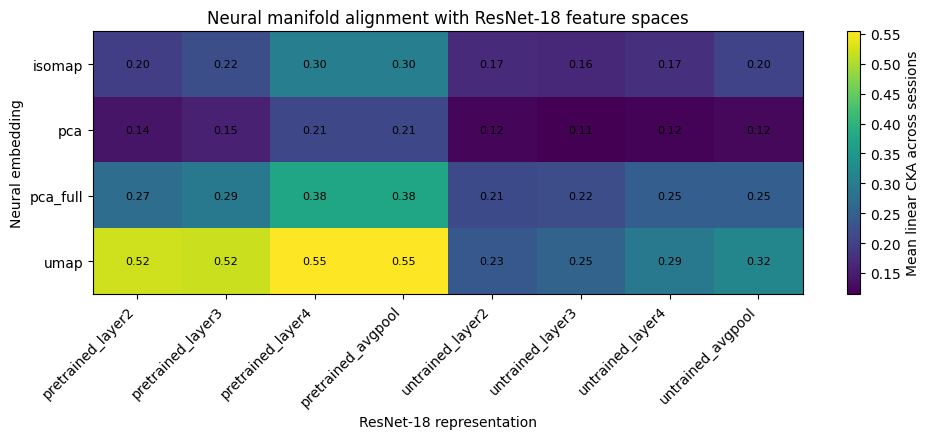

In [9]:
# ---------------------------------------------------------------------
# Notebook 15: clean DNN alignment figure
# ---------------------------------------------------------------------

summary_path = paths.publication_tables_dir / "15_brain_model_alignment_deep_multisession_summary.csv"
deep_summary = pd.read_csv(summary_path)

plot_df = deep_summary.copy()

plot_df["model_label"] = (
    plot_df["control_type"].astype(str)
    + "_"
    + plot_df["layer_name"].astype(str)
)

# Focus on linear CKA because it is the primary representation-alignment metric.
heat = (
    plot_df
    .pivot_table(
        index="neural_representation",
        columns="model_label",
        values="mean_linear_cka",
        aggfunc="mean",
    )
)

# Reorder columns if present.
preferred_cols = [
    "pretrained_layer2",
    "pretrained_layer3",
    "pretrained_layer4",
    "pretrained_avgpool",
    "untrained_layer2",
    "untrained_layer3",
    "untrained_layer4",
    "untrained_avgpool",
]

heat = heat[[c for c in preferred_cols if c in heat.columns]]

fig, ax = plt.subplots(figsize=(10, 4.5))

im = ax.imshow(heat.to_numpy(), aspect="auto")

ax.set_xticks(np.arange(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(heat.shape[0]))
ax.set_yticklabels(heat.index)

ax.set_title("Neural manifold alignment with ResNet-18 feature spaces")
ax.set_xlabel("ResNet-18 representation")
ax.set_ylabel("Neural embedding")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean linear CKA across sessions")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

fig.tight_layout()

save_figure(
    fig,
    paths.publication_figures_dir / "15_resnet18_alignment_heatmap.png",
)

plt.show()

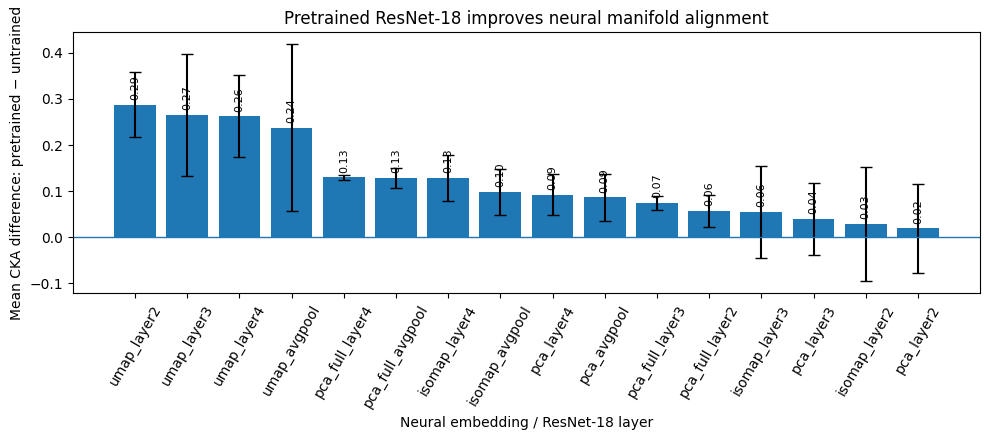

In [10]:
# ---------------------------------------------------------------------
# Notebook 15: clean pretrained-vs-untrained DNN alignment delta figure
# ---------------------------------------------------------------------

paired_summary_path = (
    paths.publication_tables_dir
    / "15_resnet18_pretrained_vs_untrained_paired_summary.csv"
)

if not paired_summary_path.exists():
    raise FileNotFoundError(f"Missing paired summary: {paired_summary_path}")

paired_summary = pd.read_csv(paired_summary_path)

if paired_summary.empty:
    raise RuntimeError("Paired pretrained-vs-untrained summary is empty.")

plot_df = paired_summary.copy()

plot_df["label"] = (
    plot_df["neural_representation"].astype(str)
    + "_"
    + plot_df["layer_name"].astype(str)
)

plot_df = plot_df.sort_values(
    "mean_linear_cka_delta",
    ascending=False,
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(
    plot_df["label"],
    plot_df["mean_linear_cka_delta"],
    yerr=plot_df["std_linear_cka_delta"].fillna(0),
    capsize=4,
)

ax.axhline(0, linewidth=1)

ax.set_xlabel("Neural embedding / ResNet-18 layer")
ax.set_ylabel("Mean CKA difference: pretrained − untrained")
ax.set_title("Pretrained ResNet-18 improves neural manifold alignment")
ax.tick_params(axis="x", rotation=60)

for i, row in plot_df.iterrows():
    ax.text(
        i,
        row["mean_linear_cka_delta"] + 0.01,
        f"{row['mean_linear_cka_delta']:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90,
    )

fig.tight_layout()

save_figure(
    fig,
    paths.publication_figures_dir
    / "15_resnet18_pretrained_minus_untrained_delta.png",
)

plt.show()

In [11]:
# ---------------------------------------------------------------------
# Notebook 15 completion checkpoint
# ---------------------------------------------------------------------

expected_outputs = [
    "15_brain_model_alignment_analytic_features.csv",
    "15_brain_model_alignment_analytic_features_status.csv",
    "15_dnn_feature_extraction_plan.csv",
    "15_dnn_extracted_feature_files.csv",
    "15_dnn_feature_extraction_status.csv",
    "15_brain_model_alignment_deep_features.csv",
    "15_brain_model_alignment_deep_features_status.csv",
    "15_brain_model_alignment_deep_features_parsed.csv",
    "15_brain_model_alignment_deep_multisession_summary.csv",
    "15_resnet18_pretrained_vs_untrained_paired_by_session.csv",
    "15_resnet18_pretrained_vs_untrained_paired_summary.csv",
]

rows = []

for name in expected_outputs:
    path = paths.publication_tables_dir / name
    rows.append({
        "file": name,
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else 0,
    })

notebook15_checkpoint = pd.DataFrame(rows)

save_table(
    notebook15_checkpoint,
    paths.publication_tables_dir / "15_notebook_completion_checkpoint.csv",
)

display(notebook15_checkpoint)

,file,exists,size_kb
0,15_brain_model_alignment_analytic_features.csv,True,4.84
1,15_brain_model_alignment_analytic_features_sta...,True,0.18
2,15_dnn_feature_extraction_plan.csv,True,13.80
3,15_dnn_extracted_feature_files.csv,True,5.48
4,15_dnn_feature_extraction_status.csv,True,6.28
5,15_brain_model_alignment_deep_features.csv,True,24.06
6,15_brain_model_alignment_deep_features_status.csv,True,6.74
7,15_brain_model_alignment_deep_features_parsed.csv,True,26.48
8,15_brain_model_alignment_deep_multisession_sum...,True,4.96
9,15_resnet18_pretrained_vs_untrained_paired_by_...,True,6.88


## Optional DNN feature → V1 population encoding

Runs only when DNN `.npy` feature arrays and neural tensors exist.

In [12]:
# ---------------------------------------------------------------------
# Notebook 15: DNN feature-to-population encoding
# ---------------------------------------------------------------------
# Tests whether pretrained/untrained ResNet-18 features predict V1
# population responses under block-wise movie cross-validation.
# ---------------------------------------------------------------------

from v1_manifold.preprocessing import load_trial_tensor_h5
from v1_manifold_publication.encoding import evaluate_population_encoding_cv
from v1_manifold_publication.decoding import movie_block_groups
from v1_manifold_publication.metrics import summarize_folds

rows = []
status_rows = []

ready = (
    asset_index
    .loc[asset_index["ready_for_population_encoding"], "session_id"]
    .astype(str)
    .tolist()
)

print("Sessions ready for DNN-to-population encoding:", ready)

n_movie_blocks = int(cfg.get("cv", {}).get("n_movie_blocks", 5))

for session_id in ready:
    tensor_path = Path(
        asset_index.loc[
            asset_index["session_id"].astype(str) == str(session_id),
            "tensor_file",
        ].iloc[0]
    )

    try:
        tensor, R = load_trial_tensor_h5(tensor_path)
        groups = movie_block_groups(R.shape[0], n_movie_blocks)

        print("\n" + "=" * 90)
        print("Session:", session_id)
        print("Tensor:", tensor_path)
        print("R shape:", R.shape)

    except Exception as exc:
        status_rows.append({
            "session_id": session_id,
            "stage": "load_tensor",
            "status": "failed",
            "reason": repr(exc),
        })
        continue

    model_files = (
        sorted(paths.versioned_processed_dir.glob(f"session_{session_id}_resnet18_*_features.npy"))
        + sorted(paths.processed_dir.glob(f"session_{session_id}_resnet18_*_features.npy"))
    )

    model_files = [
        f for f in model_files
        if "embedding" not in f.name.lower()
        and "cebra" not in f.name.lower()
    ]

    print("DNN feature files:", len(model_files))

    if not model_files:
        status_rows.append({
            "session_id": session_id,
            "stage": "dnn_to_population_encoding",
            "status": "skipped",
            "reason": "No ResNet-18 feature .npy files found.",
        })
        continue

    for model_file in model_files:
        try:
            X = np.load(model_file)

            if X.ndim != 2 or X.shape[0] != R.shape[0]:
                status_rows.append({
                    "session_id": session_id,
                    "model_feature_file": str(model_file),
                    "stage": "dnn_to_population_encoding",
                    "status": "skipped",
                    "reason": f"Shape mismatch: X={getattr(X, 'shape', None)}, R={R.shape}",
                })
                continue

            model_representation = model_file.stem.replace(
                f"session_{session_id}_",
                "",
            )

            control_type = (
                "untrained"
                if "_untrained_" in model_file.name
                else "pretrained"
                if "_pretrained_" in model_file.name
                else "unknown"
            )

            layer_name = "unknown"
            for candidate_layer in ["layer2", "layer3", "layer4", "avgpool"]:
                if candidate_layer in model_file.name:
                    layer_name = candidate_layer
                    break

            print(
                f"Encoding: session={session_id}, model={model_representation}, "
                f"X={X.shape}, R={R.shape}"
            )

            df, pred = evaluate_population_encoding_cv(
                X,
                R,
                groups=groups,
                model_name="ridge_cv",
                n_splits=len(np.unique(groups)),
            )

            if df is None or df.empty:
                status_rows.append({
                    "session_id": session_id,
                    "model_feature_file": str(model_file),
                    "model_representation": model_representation,
                    "stage": "dnn_to_population_encoding",
                    "status": "empty_result",
                })
                continue

            df = df.copy()
            df["session_id"] = session_id
            df["model_feature_file"] = str(model_file)
            df["model_representation"] = model_representation
            df["model_family"] = "resnet18"
            df["control_type"] = control_type
            df["layer_name"] = layer_name
            df["encoding_model"] = "ridge_cv"
            rows.append(df)

            status_rows.append({
                "session_id": session_id,
                "model_feature_file": str(model_file),
                "model_representation": model_representation,
                "stage": "dnn_to_population_encoding",
                "status": "completed",
                "shape": str(X.shape),
                "n_rows": len(df),
            })

        except Exception as exc:
            status_rows.append({
                "session_id": session_id,
                "model_feature_file": str(model_file),
                "stage": "dnn_to_population_encoding",
                "status": "failed",
                "reason": repr(exc),
            })

dnn_encoding = (
    pd.concat(rows, ignore_index=True)
    if rows
    else pd.DataFrame()
)

dnn_status = pd.DataFrame(status_rows)

save_table(
    dnn_encoding,
    paths.publication_tables_dir / "15_dnn_to_population_encoding_folds.csv",
)

save_table(
    dnn_status,
    paths.publication_tables_dir / "15_dnn_to_population_encoding_status.csv",
)

if dnn_encoding.empty:
    print("No DNN-to-population encoding rows were produced.")
    display(dnn_status.head(50))
else:
    metric_col = (
        "population_spearman_r"
        if "population_spearman_r" in dnn_encoding.columns
        else "population_pearson_r"
        if "population_pearson_r" in dnn_encoding.columns
        else "population_r2"
    )

    dnn_encoding_summary = summarize_folds(
        dnn_encoding.dropna(subset=[metric_col]),
        group_cols=[
            "session_id",
            "model_representation",
            "model_family",
            "control_type",
            "layer_name",
            "encoding_model",
        ],
    )

    save_table(
        dnn_encoding_summary,
        paths.publication_tables_dir / "15_dnn_to_population_encoding_summary.csv",
    )

    display(
        dnn_encoding_summary
        .sort_values(
            f"{metric_col}_mean"
            if f"{metric_col}_mean" in dnn_encoding_summary.columns
            else metric_col,
            ascending=False,
        )
        .head(40)
    )

    display(dnn_status.head(80))

Sessions ready for DNN-to-population encoding: ['500855614', '500964514', '501271265']

Session: 500855614
Tensor: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\interim\session_500855614_natural_movie_one_tensor.h5
R shape: (900, 163)
DNN feature files: 8
Encoding: session=500855614, model=resnet18_pretrained_avgpool_features, X=(900, 512), R=(900, 163)
Encoding: session=500855614, model=resnet18_pretrained_layer2_features, X=(900, 128), R=(900, 163)
Encoding: session=500855614, model=resnet18_pretrained_layer3_features, X=(900, 256), R=(900, 163)
Encoding: session=500855614, model=resnet18_pretrained_layer4_features, X=(900, 512), R=(900, 163)
Encoding: session=500855614, model=resnet18_untrained_avgpool_features, X=(900, 512), R=(900, 163)
Encoding: session=500855614, model=resnet18_untrained_layer2_features, X=(900, 128), R=(900, 163)
Encoding: session=500855614, model=resnet18_untrained_layer3_features, X=(900, 256), R=(900, 163)
Encoding: session

,session_id,model_representation,model_family,control_type,layer_name,encoding_model,fold_mean,fold_std,fold_median,n_train_mean,...,population_mae_median,population_rmse_mean,population_rmse_std,population_rmse_median,population_spearman_r_mean,population_spearman_r_std,population_spearman_r_median,population_pearson_r_mean,population_pearson_r_std,population_pearson_r_median
7,500855614,resnet18_untrained_layer4_features,resnet18,untrained,layer4,ridge_cv,2.0,1.581139,2.0,720.0,...,0.597685,1.116202,0.185101,1.089469,0.115814,0.027574,0.122878,0.162375,0.093499,0.129312
4,500855614,resnet18_untrained_avgpool_features,resnet18,untrained,avgpool,ridge_cv,2.0,1.581139,2.0,720.0,...,0.634361,1.100188,0.128422,1.093514,0.105534,0.032365,0.107002,0.173385,0.089769,0.154504
2,500855614,resnet18_pretrained_layer3_features,resnet18,pretrained,layer3,ridge_cv,2.0,1.581139,2.0,720.0,...,0.692119,1.174450,0.230998,1.241808,0.099484,0.026113,0.094938,0.064647,0.088252,0.067078
1,500855614,resnet18_pretrained_layer2_features,resnet18,pretrained,layer2,ridge_cv,2.0,1.581139,2.0,720.0,...,0.763786,1.252651,0.231015,1.403033,0.094177,0.015382,0.094815,0.088099,0.024088,0.081503
12,500964514,resnet18_untrained_avgpool_features,resnet18,untrained,avgpool,ridge_cv,2.0,1.581139,2.0,720.0,...,0.535641,1.035148,0.232586,0.979489,0.092048,0.034653,0.085389,0.102628,0.059223,0.082296
15,500964514,resnet18_untrained_layer4_features,resnet18,untrained,layer4,ridge_cv,2.0,1.581139,2.0,720.0,...,0.553236,1.070469,0.240502,1.015152,0.087415,0.040260,0.075984,0.089496,0.071346,0.072213
0,500855614,resnet18_pretrained_avgpool_features,resnet18,pretrained,avgpool,ridge_cv,2.0,1.581139,2.0,720.0,...,0.645379,1.110327,0.196205,1.127603,0.086439,0.027064,0.096661,0.082196,0.051482,0.070552
3,500855614,resnet18_pretrained_layer4_features,resnet18,pretrained,layer4,ridge_cv,2.0,1.581139,2.0,720.0,...,0.645379,1.110327,0.196205,1.127603,0.086439,0.027064,0.096661,0.082196,0.051482,0.070552
11,500964514,resnet18_pretrained_layer4_features,resnet18,pretrained,layer4,ridge_cv,2.0,1.581139,2.0,720.0,...,0.528625,1.014877,0.246017,0.972489,0.083546,0.022145,0.076796,0.102464,0.082673,0.110483
8,500964514,resnet18_pretrained_avgpool_features,resnet18,pretrained,avgpool,ridge_cv,2.0,1.581139,2.0,720.0,...,0.528625,1.014877,0.246017,0.972489,0.083546,0.022145,0.076796,0.102464,0.082673,0.110483


,session_id,model_feature_file,model_representation,stage,status,shape,n_rows
0,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_avgpool_features,dnn_to_population_encoding,completed,"(900, 512)",5
1,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer2_features,dnn_to_population_encoding,completed,"(900, 128)",5
2,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer3_features,dnn_to_population_encoding,completed,"(900, 256)",5
3,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer4_features,dnn_to_population_encoding,completed,"(900, 512)",5
4,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_avgpool_features,dnn_to_population_encoding,completed,"(900, 512)",5
5,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_layer2_features,dnn_to_population_encoding,completed,"(900, 128)",5
6,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_layer3_features,dnn_to_population_encoding,completed,"(900, 256)",5
7,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_untrained_layer4_features,dnn_to_population_encoding,completed,"(900, 512)",5
8,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_avgpool_features,dnn_to_population_encoding,completed,"(900, 512)",5
9,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,resnet18_pretrained_layer2_features,dnn_to_population_encoding,completed,"(900, 128)",5
